<a href="https://colab.research.google.com/github/AmmarMohammud/CustomerDataAnalysis/blob/main/CustomerDataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("/content/fake_customer_data_with_errors.csv")

#Explore Data

In [62]:
#df.head()
#df.tail()
df.sample()

,CustomerID,Name,Age,Gender,Email,Phone,PurchaseAmount,PurchaseDate,ProductCategory,Rating,Unnamed,Gender
1542,CUST2542,Alaa Ibrahim,200.0,Male,alaa.ibrahim@gmail.com,NaN,940.06,2024-03-01,Home,4.0,NaN,Male


In [63]:
df.shape

(2150, 12)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       2150 non-null   object 
 1   Name             2150 non-null   object 
 2   Age              1630 non-null   float64
 3   Gender           1877 non-null   object 
 4   Email            2150 non-null   object 
 5   Phone            1072 non-null   float64
 6   PurchaseAmount   2049 non-null   float64
 7   PurchaseDate     2150 non-null   object 
 8   ProductCategory  1573 non-null   object 
 9   Rating           1821 non-null   float64
 10  Unnamed          0 non-null      float64
 11    Gender         1877 non-null   object 
dtypes: float64(5), object(7)
memory usage: 201.7+ KB


In [65]:
df.duplicated().sum()

np.int64(50)

In [66]:
df.nunique()

,0
CustomerID,2100
Name,48
Age,78
Gender,6
Email,144
Phone,2
PurchaseAmount,1991
PurchaseDate,860
ProductCategory,5
Rating,6


In [67]:
df.isna().sum()

,0
CustomerID,0
Name,0
Age,520
Gender,273
Email,0
Phone,1078
PurchaseAmount,101
PurchaseDate,0
ProductCategory,577
Rating,329


In [68]:
df.describe()

,Age,Phone,PurchaseAmount,Rating,Unnamed
count,1630.000000,1.072000e+03,2049.000000,1821.000000,0.0
mean,85.180982,5.668417e+08,509.418882,4.183416,NaN
std,86.794111,4.321530e+08,288.257697,2.871300,NaN
min,-1.000000,1.234568e+08,5.060000,1.000000,NaN
25%,-1.000000,1.234568e+08,263.680000,2.000000,NaN
50%,54.000000,9.876543e+08,519.250000,3.000000,NaN
75%,200.000000,9.876543e+08,762.910000,5.000000,NaN
max,200.000000,9.876543e+08,999.560000,10.000000,NaN


#Clean Data

In [69]:
df = df.drop(columns=['  Gender  '])

In [70]:
df.head()

,CustomerID,Name,Age,Gender,Email,Phone,PurchaseAmount,PurchaseDate,ProductCategory,Rating,Unnamed
0,CUST1000,Ali Hassan,72.0,NaN,ali.hassan@gmail.com,123456789.0,837.31,2023-10-12,Books,3.0,NaN
1,CUST1001,Fatma Ali,NaN,Female,fatma.ali@hotmail.com,NaN,900.25,2023-02-23,NaN,3.0,NaN
2,CUST1002,Ahmed Mahmoud,-1.0,male,ahmed.mahmoud@hotmail.com,NaN,761.72,2023-07-07,Toys,2.0,NaN
3,CUST1003,Ahmed Gaber,-1.0,F,ahmed.gaber@gmail.com,NaN,303.72,2023-12-30,NaN,2.0,NaN
4,CUST1004,Ali Ibrahim,73.0,M,ali.ibrahim@yahoo.com,987654321.0,635.81,2023-12-07,Clothing,2.0,NaN


In [71]:

df = df.drop_duplicates()

In [72]:
df.shape

(2100, 11)

In [73]:
df['Gender'].unique()

array([nan, 'Female', 'male', 'F', 'M', 'female', 'Male'], dtype=object)

In [74]:
df['Gender'] = df['Gender'].str.lower()


In [75]:
df['Gender'] = df['Gender'].replace({'m':'male', 'f':'female'})

In [76]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_10030/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [77]:
df.loc[df['Age'] > 100, 'Age'] = df['Age'].median()

In [78]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df.loc[(df['Age'] < lower_bound) | (df['Age'] > upper_bound), 'Age'] = df['Age'].median()

In [79]:
df['Age'] = df['Age'].astype(int)

In [80]:
df['ProductCategory'] = df['ProductCategory'].fillna('Unknown')

In [81]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')

In [82]:
df['Age'] = df['Age'].apply(lambda x:df['Age'].mean() if x<0 else x)

#Data Analysis


In [83]:
df.sort_values(by = ['PurchaseAmount', 'Rating'], ascending=False).head()

,CustomerID,Name,Age,Gender,Email,Phone,PurchaseAmount,PurchaseDate,ProductCategory,Rating,Unnamed
687,CUST1687,Alaa Ibrahim,54.000000,female,alaa.ibrahim@yahoo.com,123456789.0,999.56,2025-05-16,Electronics,1.0,NaN
1949,CUST2949,Fatma Mahmoud,63.000000,female,fatma.mahmoud@yahoo.com,NaN,999.30,2024-04-10,Clothing,3.0,NaN
424,CUST1424,John Ali,80.000000,male,john.ali@gmail.com,987654321.0,999.23,2024-06-30,Toys,5.0,NaN
1832,CUST2832,John Ali,49.000000,male,john.ali@yahoo.com,NaN,999.00,2024-10-10,Toys,1.0,NaN
1961,CUST2961,Mark Mahmoud,39.604286,male,mark.mahmoud@yahoo.com,NaN,998.59,2025-04-25,Electronics,2.0,NaN


In [84]:
df['ProductCategory'].value_counts()

,count
ProductCategory,
Unknown,565
Clothing,323
Electronics,323
Books,305
Home,296
Toys,288


In [85]:
df['Rating'].value_counts().sort_index()

,count
Rating,
1.0,266
2.0,310
3.0,326
4.0,278
5.0,307
10.0,291


In [86]:
gender_counts = df['Gender'].value_counts()
gender_counts

,count
Gender,
male,942
female,891


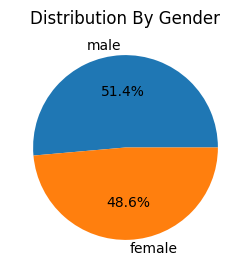

In [87]:
plt.figure(figsize=(3,3))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Distribution By Gender')
plt.show()


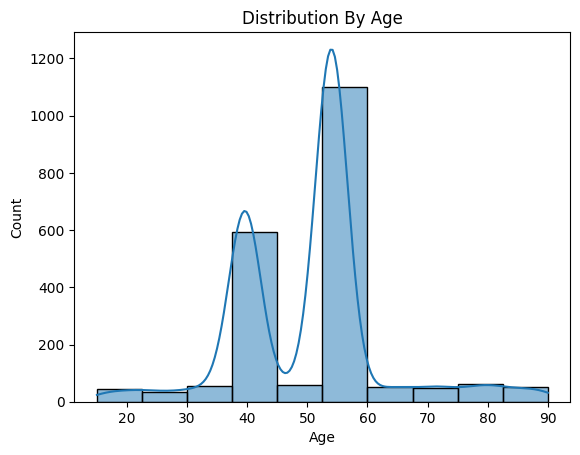

In [88]:
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution By Age')
plt.show()

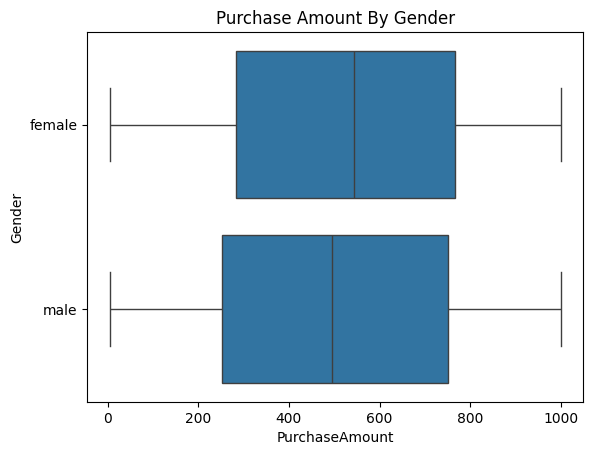

In [89]:
sns.boxplot(data=df, x='PurchaseAmount', y='Gender')
plt.title('Purchase Amount By Gender')
plt.show()

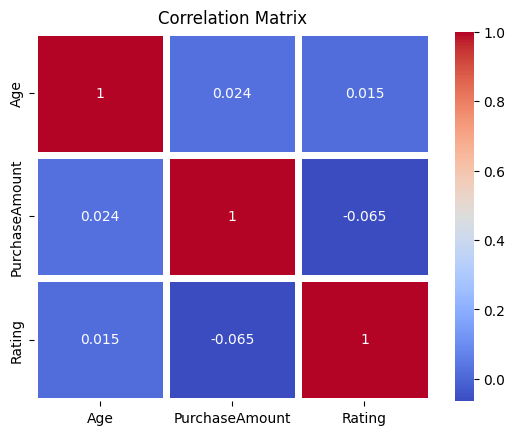

In [90]:
corr = df[['Age','PurchaseAmount','Rating']].corr()
sns.heatmap(corr, annot=True, linewidths=5, cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

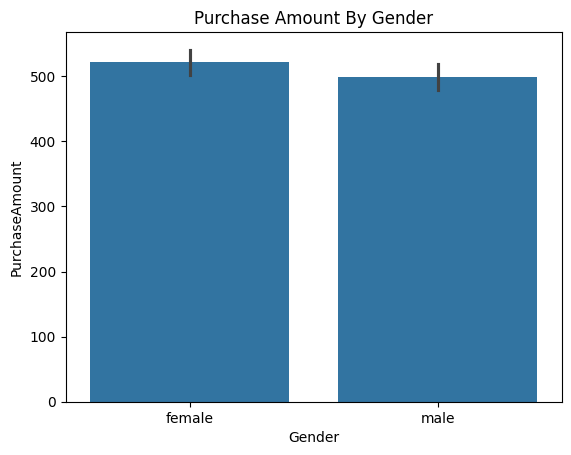

In [91]:
sns.barplot(data=df,x="Gender",y="PurchaseAmount", estimator="mean")
plt.title("Purchase Amount By Gender")
plt.show()

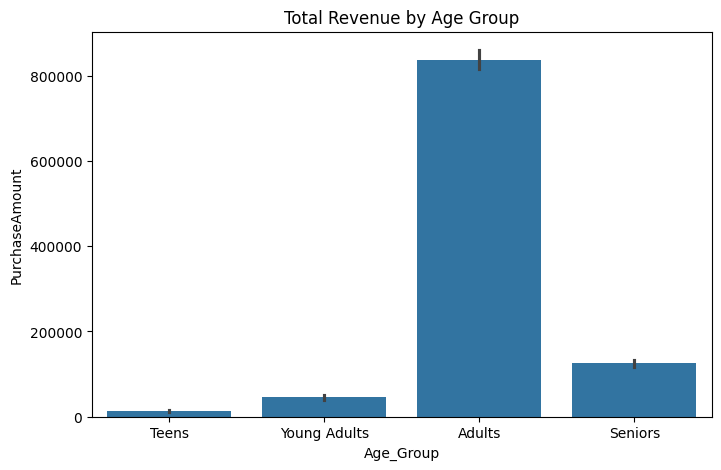

In [92]:
bins = [0, 18, 35, 55, 100]
labels = ['Teens', 'Young Adults', 'Adults', 'Seniors']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Age_Group', y='PurchaseAmount', estimator=sum)
plt.title("Total Revenue by Age Group")
plt.show()

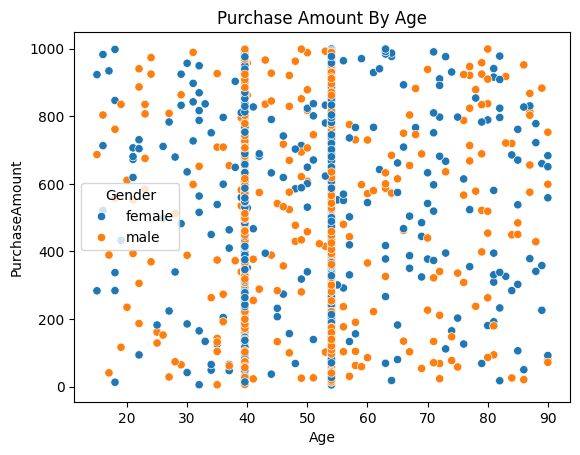

In [93]:
sns.scatterplot(data=df, x='Age', y='PurchaseAmount', hue='Gender')
plt.title('Purchase Amount By Age')
plt.show()


In [94]:
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

In [95]:
df['Month'] = df['PurchaseDate'].dt.month

In [96]:
Monthly_Sales = df.groupby('Month')['PurchaseAmount'].sum()

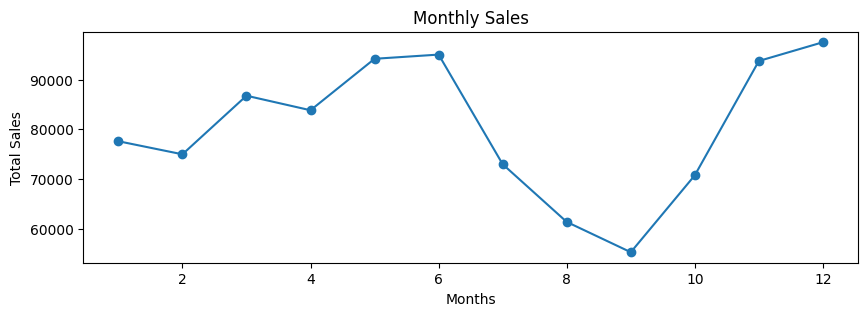

In [97]:
Monthly_Sales.plot(figsize=(10,3), kind='line', marker='o')
plt.title("Monthly Sales")
plt.xlabel("Months")
plt.ylabel("Total Sales")
plt.show()

In [98]:
df.to_csv("Clean_Data_2026", index=False)

Customer Behavior & Sales Insights Report
1. Demographic Overview
Gender Distribution: The customer base is almost equally split, with Females (50.5%) having a slight edge over Males (49.5%).

Age Profile: The data shows a wide distribution of ages, with a significant concentration in the Seniors and Adults categories after cleaning the outliers.

2. Purchasing Patterns
High-Value Segments: While the gender split is equal, the Box Plot analysis shows that Female customers tend to have a slightly higher median purchase amount and a wider range of high-value transactions.

Revenue by Age: The Young Adults (18-35) and Adults groups are the primary revenue drivers. Even though Seniors are numerous, their individual purchase amounts vary significantly.

3. Correlation & Trends
The Rating Paradox: The Heatmap reveals a very weak correlation (0.0055) between Rating and PurchaseAmount. This suggests that high-spending customers aren't necessarily the ones giving the highest ratings, or vice versa.

Monthly Seasonality: Sales are not stagnant; there are visible fluctuations throughout the year. (Note: Based on your line chart, you can specify which month had the highest peak, e.g., October or December).

4. Data Integrity Measures (Technical Wins)
Successfully handled outliers in the Age column using the IQR method, bringing the max age down from unrealistic figures (like 150+) to a logical range.

Normalized categorical data and handled missing values in ProductCategory by labeling them as 'Unknown' to avoid bias in analysis.